# Smart Energy Consumption Predictor
## Exploratory analysis, modelling and evaluation

**Task:** forecast hourly household electricity demand (kW) with a Ridge-regression model and a stacked LSTM, and compare both with naive baselines.

**Sections**
1. Data loading & quality checks
2. Cleaning & feature engineering (and why these features)
3. Exploratory analysis
4. Chronological split, scaling, windowing
5. Baselines, Ridge, LSTM
6. Evaluation – one-step metrics (kW), residuals, multi-step back-test
7. Interpretability – which inputs does Ridge use?
8. Anomaly detection (four methods, scored against injected spikes)
9. Optimisation suggestions
10. Conclusions & limitations

> The notebook uses the **synthetic** dataset so it runs anywhere. To run on the real UCI data, place `household_power_consumption.txt` in `data/` and set `USE_SYNTHETIC = False` in the first code cell.

In [1]:
import sys, os, warnings, logging
sys.path.insert(0, os.path.abspath('..'))
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

logging.basicConfig(level=logging.WARNING)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 100, 'figure.figsize': (12, 4.5)})

USE_SYNTHETIC = True      # set False to use the real UCI file in data/
LOOK_BACK = 24            # hours of history fed to the models
SEED = 42
print('Setup OK')

Setup OK


## 1. Load data & quality checks

In [2]:
from models import data_loader as dl

raw = dl.load_raw(use_synthetic=USE_SYNTHETIC)
hourly = dl.to_hourly(raw)
print('Raw shape   :', raw.shape, '| frequency:', pd.infer_freq(raw.index[:10]))
print('Hourly shape:', hourly.shape, '|', hourly.index.min(), '→', hourly.index.max())
print('Missing values in raw data:\n', raw.isna().sum().to_string())
display(hourly.describe().round(3))

Raw shape   : (17520, 7) | frequency: h
Hourly shape: (17520, 7) | 2023-01-01 00:00:00 → 2024-12-30 23:00:00
Missing values in raw data:
 Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
count,17520.000,17520.000,17520.000,17520.000,17520.000,17520.000,17520.000
mean,1.076,0.093,239.694,4.514,0.706,0.512,5.223
std,0.567,0.030,1.652,2.396,0.838,0.568,1.964
min,0.100,0.000,231.758,0.200,0.000,0.000,0.000
25%,0.660,0.072,238.585,2.760,0.174,0.134,3.839
50%,0.979,0.091,239.708,4.124,0.434,0.331,5.023
75%,1.414,0.112,240.812,5.943,0.928,0.692,6.417
max,5.881,0.277,245.910,24.144,11.921,8.191,20.453


In [3]:
# Sanity check: the target must actually vary (a flat target makes every metric meaningless)
y = hourly['Global_active_power']
assert y.std() > 0.1, 'target is (nearly) constant!'
print(f'Target: mean={y.mean():.3f} kW  std={y.std():.3f}  min={y.min():.3f}  max={y.max():.3f}')

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.flat, dl.RAW_COLS[:6]):
    hourly[col].hist(ax=ax, bins=50, alpha=.85)
    ax.set_title(col)
fig.suptitle('Distributions of the raw hourly variables', y=1.01)
plt.tight_layout(); plt.show()

Target: mean=1.076 kW  std=0.567  min=0.100  max=5.881


<Figure size 1400x700 with 6 Axes>

## 2. Cleaning & feature engineering

**Cleaning**
* Missing values: short gaps (≤ 6 h) are interpolated; longer gaps use the value from 24 h earlier.
* Outliers: the target is clipped at `Q1 − 4·IQR … Q3 + 4·IQR` with quartiles computed **on the training period only** (so the test period cannot influence preprocessing).

**Features** (all computable at forecast time):

| Feature | Why |
|---|---|
| `Global_active_power` (history) | autoregressive signal |
| `hour_sin`, `hour_cos` | daily cycle, continuous (23 h is close to 0 h) |
| `day_of_week`, `is_weekend`, `month` | weekly and annual seasonality |
| `rolling_mean_24h`, `rolling_std_24h` | recent level and volatility |
| `lag_24h`, `lag_168h` | same hour yesterday / last week |

**Deliberately excluded:** voltage, current, sub-metering and reactive power. They are measured *at the same time* as the target, so they are unknown when forecasting, and `Global_intensity` is almost a deterministic function of active power (P ≈ V·I), which would make the task trivially easy and the forecast impossible to run into the future.

In [4]:
data = dl.get_processed_data(look_back=LOOK_BACK, use_synthetic=USE_SYNTHETIC, save=False)
feats = data['features']
print('Feature matrix:', feats.shape)
print('Clip bounds (train quartiles): %.2f – %.2f kW' % data['clip_bounds'])
display(feats.head(3).round(3))

Feature matrix: (17352, 10)
Clip bounds (train quartiles): 0.00 – 4.43 kW


,Global_active_power,hour_sin,hour_cos,day_of_week,is_weekend,month,rolling_mean_24h,rolling_std_24h,lag_24h,lag_168h
2023-01-08 00:00:00,0.743,0.000,1.000,6,1,1,1.375,0.604,0.461,0.684
2023-01-08 01:00:00,0.713,0.259,0.966,6,1,1,1.385,0.590,0.476,0.496
2023-01-08 02:00:00,0.585,0.500,0.866,6,1,1,1.391,0.582,0.450,0.706


## 3. Exploratory analysis

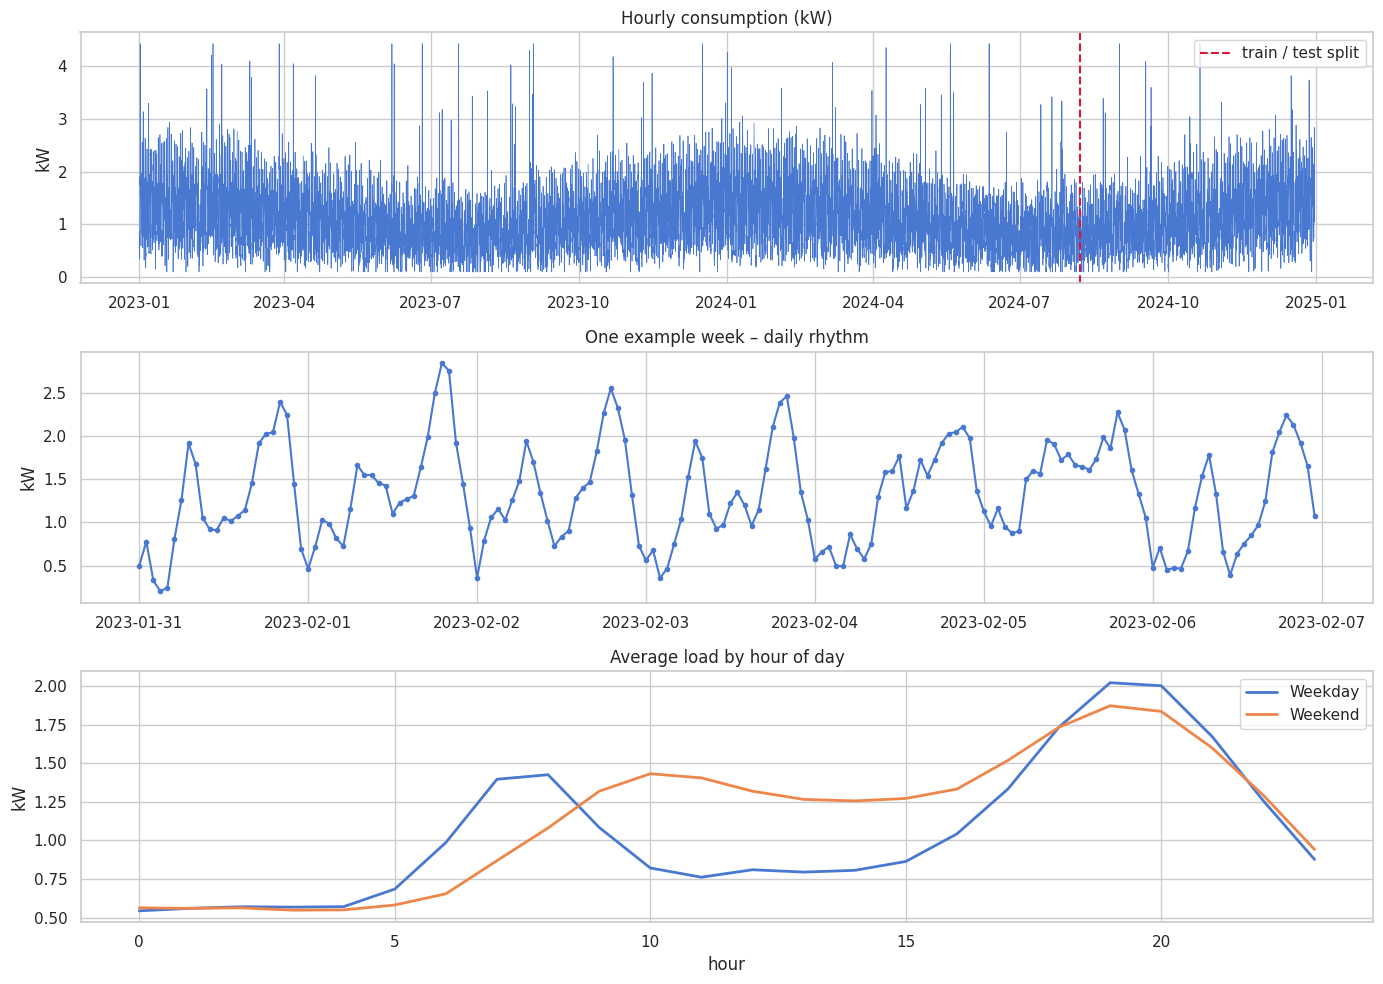

In [5]:
y = data['y_hourly']
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

axes[0].plot(y.index, y.values, lw=.5)
axes[0].axvline(data['split_ts'], color='crimson', ls='--', label='train / test split')
axes[0].set(title='Hourly consumption (kW)', ylabel='kW'); axes[0].legend()

week = y.iloc[24*30: 24*37]
axes[1].plot(week.index, week.values, marker='o', ms=3)
axes[1].set(title='One example week – daily rhythm', ylabel='kW')

wk = y.groupby([y.index.hour, y.index.dayofweek >= 5]).mean().unstack()
wk.columns = ['Weekday', 'Weekend']
wk.plot(ax=axes[2], lw=2)
axes[2].set(title='Average load by hour of day', xlabel='hour', ylabel='kW')
plt.tight_layout(); plt.show()

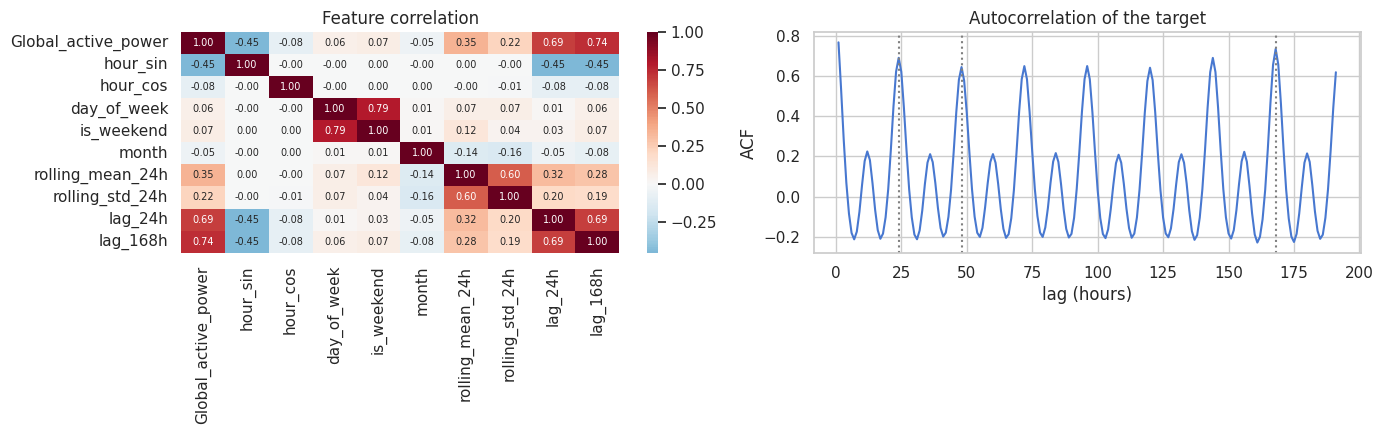

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
corr = feats.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, annot_kws={'size': 7}, ax=axes[0])
axes[0].set_title('Feature correlation')

from pandas.plotting import autocorrelation_plot
lags = np.arange(1, 24*8)
acf = [y.autocorr(l) for l in lags]
axes[1].plot(lags, acf); axes[1].set(title='Autocorrelation of the target', xlabel='lag (hours)', ylabel='ACF')
for l in (24, 48, 168): axes[1].axvline(l, color='grey', ls=':')
plt.tight_layout(); plt.show()

The autocorrelation peaks at 24 h and 168 h confirm the daily and weekly seasonality – this is why `lag_24h` / `lag_168h` are included and why a *seasonal-naive* baseline is a hard one to beat.

## 4. Chronological split, scaling, windowing
* Split: first 80 % of time = train, last 20 % = test. **No shuffling** (that would let the model peek at the future).
* `MinMaxScaler` is fitted on the training rows only.
* Each sample is a window of `LOOK_BACK` consecutive hours; the target is the **next** hour.
* The last 15 % of the training windows form a validation set for early stopping – the test set is only used once, for the final numbers.

In [7]:
print('Train windows :', data['X_train_seq'].shape, '| ends before', data['split_ts'])
print('Test  windows :', data['X_test_seq'].shape,  '| starts at', data['test_index'][0])
assert data['test_index'].min() >= data['split_ts']          # no leakage

X_tr, y_tr = data['X_train_seq'], data['y_train_seq']
v = int(len(X_tr) * 0.85)
X_fit, y_fit, X_val, y_val = X_tr[:v], y_tr[:v], X_tr[v:], y_tr[v:]
X_te, y_kw = data['X_test_seq'], data['y_test_kw']
scaler = data['scaler']
inv = lambda a: dl.inverse_target(a, scaler)

Train windows : (13824, 24, 10) | ends before 2024-08-07 00:00:00
Test  windows : (3504, 24, 10) | starts at 2024-08-07 00:00:00


## 5. Models
### 5a. Naive baselines
Any useful model must beat these: *persistence* (next hour = this hour) and *seasonal naive* (next hour = same hour yesterday).

In [8]:
from models.metrics import evaluate_predictions, compare_models
preds = {}
preds['Persistence']   = inv(X_te[:, -1, 0])     # last observed hour
preds['SeasonalNaive'] = inv(X_te[:, 0, 0])      # window row 0 = 24 h ago
for k in preds: evaluate_predictions(y_kw, preds[k], k)

[Persistence]  MAE=0.25853  RMSE=0.37945  R²=0.53585  MAPE=30.342%
[SeasonalNaive]  MAE=0.31542  RMSE=0.43683  R²=0.38486  MAPE=42.685%


### 5b. Ridge regression
Alpha is chosen by **time-series cross-validation** (expanding window), not by looking at the test set.

In [9]:
from models.linear_model import train_linear, predict_linear, ALPHA_GRID
lr = train_linear(data['X_train_flat'], y_tr)
print('Selected alpha:', lr.named_steps['ridge'].alpha, 'from grid', ALPHA_GRID)
preds['LinearRegression'] = inv(predict_linear(lr, data['X_test_flat']))
evaluate_predictions(y_kw, preds['LinearRegression'], 'LinearRegression');

Selected alpha: 10.0 from grid [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]
[LinearRegression]  MAE=0.17863  RMSE=0.27031  R²=0.76446  MAPE=23.949%


### 5c. LSTM
Two stacked LSTM layers (128, 64) with dropout, Huber loss, Adam, early stopping and learning-rate reduction. (The notebook writes its checkpoint to a temp file so it does not overwrite the model the web app uses.)

In [10]:
import tensorflow as tf
import models.lstm_model as lm
lm.LSTM_PATH = '/tmp/notebook_lstm.keras'            # do not clobber models/saved/

lstm, hist = lm.train_lstm(X_fit, y_fit, X_val, y_val, epochs=40, batch_size=64, patience=6, seed=SEED)
preds['LSTM'] = inv(lm.predict_lstm(lstm, X_te))
print('Epochs run:', len(hist['loss']), '| best val loss: %.5f' % min(hist['val_loss']))
evaluate_predictions(y_kw, preds['LSTM'], 'LSTM');

Epoch 1/40


  1/184 ━━━━━━━━━━━━━━━━━━━━ 9:05 3s/step - loss: 0.0361 - mae: 0.2293

  3/184 ━━━━━━━━━━━━━━━━━━━━ 8s 48ms/step - loss: 0.0207 - mae: 0.1624

  4/184 ━━━━━━━━━━━━━━━━━━━━ 9s 51ms/step - loss: 0.0178 - mae: 0.1496

  5/184 ━━━━━━━━━━━━━━━━━━━━ 9s 52ms/step - loss: 0.0160 - mae: 0.1417

...

183/184 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.0018 - mae: 0.0389

184/184 ━━━━━━━━━━━━━━━━━━━━ 9s 46ms/step - loss: 0.0018 - mae: 0.0389 - val_loss: 0.0019 - val_mae: 0.0375 - learning_rate: 1.5625e-05


Epoch 40: early stopping


Restoring model weights from the end of the best epoch: 34.


Epochs run: 40 | best val loss: 0.00185
[LSTM]  MAE=0.16262  RMSE=0.25136  R²=0.79633  MAPE=22.029%


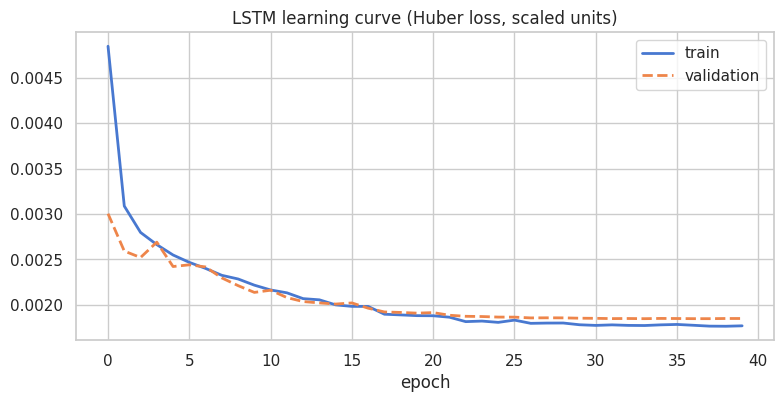

In [11]:
plt.figure(figsize=(9, 4))
plt.plot(hist['loss'], lw=2, label='train'); plt.plot(hist['val_loss'], lw=2, ls='--', label='validation')
plt.title('LSTM learning curve (Huber loss, scaled units)'); plt.xlabel('epoch'); plt.legend(); plt.show()

The validation curve flattening (and early stopping triggering) shows when the model stopped learning useful structure; a growing gap between train and validation loss would indicate over-fitting.

## 6. Evaluation
### 6a. One-step-ahead metrics on the held-out test period (kW)

In [12]:
results = {k: evaluate_predictions(y_kw, preds[k]) for k in ['Persistence', 'SeasonalNaive', 'LinearRegression', 'LSTM']}
table = pd.DataFrame(results).T
base = table.loc['Persistence', 'rmse']
table['RMSE vs persistence'] = ((1 - table['rmse'] / base) * 100).round(1).astype(str) + ' %'
display(table.sort_values('rmse'))

,mae,rmse,r2,mape,RMSE vs persistence
LSTM,0.16262,0.25136,0.79633,22.029,33.8 %
LinearRegression,0.17863,0.27031,0.76446,23.949,28.8 %
Persistence,0.25853,0.37945,0.53585,30.342,0.0 %
SeasonalNaive,0.31542,0.43683,0.38486,42.685,-15.1 %


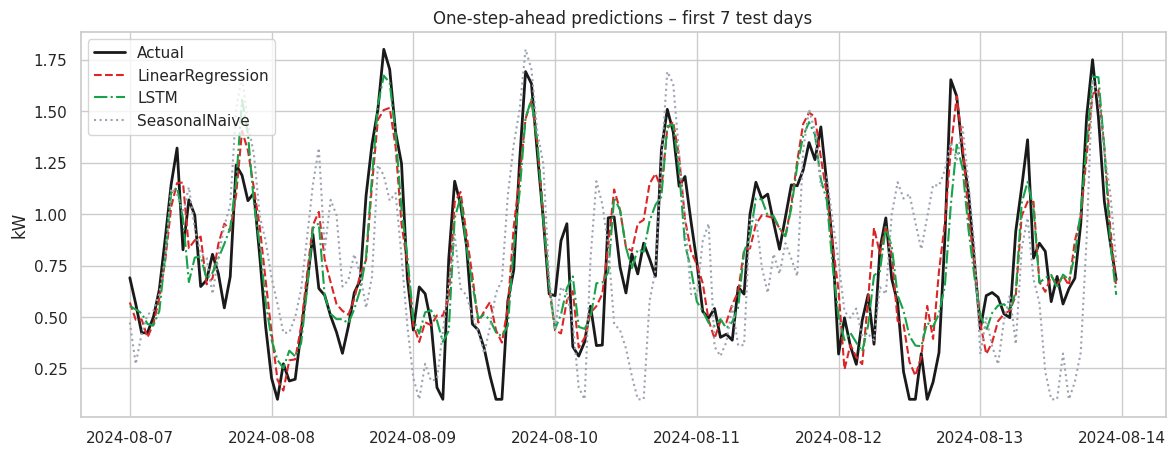

In [13]:
n = 168
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(data['test_index'][:n], y_kw[:n], 'k', lw=2, label='Actual')
for name, c, ls in [('LinearRegression', '#dc2626', '--'), ('LSTM', '#16a34a', '-.'), ('SeasonalNaive', '#9ca3af', ':')]:
    ax.plot(data['test_index'][:n], preds[name][:n], c=c, ls=ls, lw=1.5, label=name)
ax.set(title='One-step-ahead predictions – first 7 test days', ylabel='kW'); ax.legend(); plt.show()

### 6b. Residual analysis
Good residuals are centred on zero, have no obvious pattern against time of day, and no strong autocorrelation.

Best learned model: LSTM


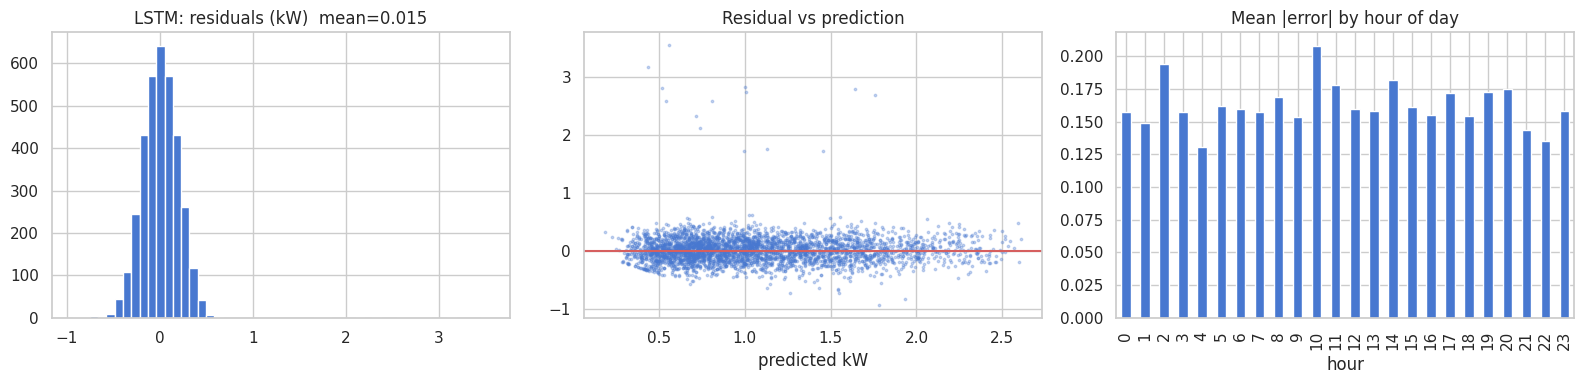

Residual lag-1 autocorrelation: 0.009


In [14]:
best = table['rmse'].drop(['Persistence', 'SeasonalNaive']).idxmin()
res = y_kw - preds[best]
print('Best learned model:', best)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].hist(res, bins=50); axes[0].set(title=f'{best}: residuals (kW)  mean={res.mean():.3f}')
axes[1].scatter(preds[best], res, s=3, alpha=.3); axes[1].axhline(0, c='r')
axes[1].set(title='Residual vs prediction', xlabel='predicted kW')
byhour = pd.Series(np.abs(res), index=data['test_index']).groupby(data['test_index'].hour).mean()
byhour.plot.bar(ax=axes[2]); axes[2].set(title='Mean |error| by hour of day', xlabel='hour')
plt.tight_layout(); plt.show()
print('Residual lag-1 autocorrelation: %.3f' % pd.Series(res).autocorr(1))

### 6c. Multi-step back-test (recursive forecasting)
The web app forecasts up to 72 h ahead by feeding each prediction back in as input, so errors compound. Here we measure that honestly from many forecast origins in the test period.

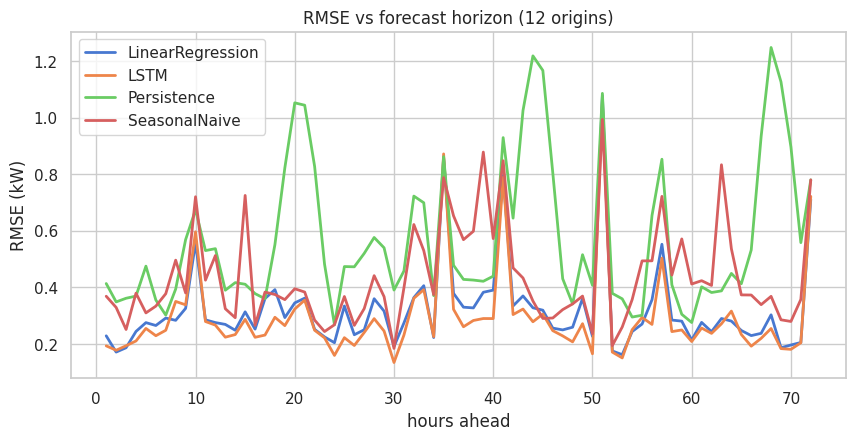

,LinearRegression,LSTM,Persistence,SeasonalNaive
1 h,0.229,0.194,0.414,0.369
24 h,0.205,0.160,0.268,0.268
72 h,0.711,0.722,0.780,0.780


In [15]:
from models.forecaster import make_predict_fn, backtest_horizons
bt = backtest_horizons(data['y_hourly'], data['split_ts'],
                       {'LinearRegression': make_predict_fn('linear', lr),
                        'LSTM': make_predict_fn('lstm', lstm)},
                       scaler, look_back=LOOK_BACK, horizon=72, n_origins=12)
fig, ax = plt.subplots(figsize=(10, 4.5))
for k, r in bt['rmse'].items(): ax.plot(range(1, 73), r, lw=2, label=k)
ax.set(title=f"RMSE vs forecast horizon ({bt['n_origins']} origins)", xlabel='hours ahead', ylabel='RMSE (kW)'); ax.legend(); plt.show()
display(pd.DataFrame({k: [r[0], r[23], r[71]] for k, r in bt['rmse'].items()},
                     index=['1 h', '24 h', '72 h']).round(3))

## 7. Interpretability – what does Ridge look at?
Coefficients on standardised inputs are comparable. Summing |coefficient| over the 24 window positions gives one importance score per feature.

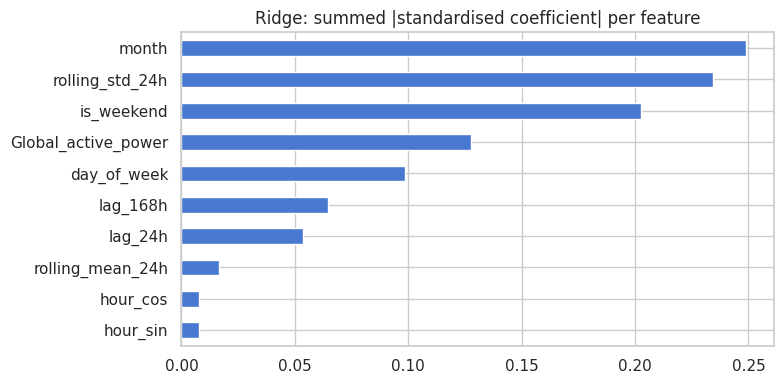

In [16]:
coef = lr.named_steps['ridge'].coef_.reshape(LOOK_BACK, len(dl.FEATURE_COLS))
imp = pd.Series(np.abs(coef).sum(axis=0), index=dl.FEATURE_COLS).sort_values()
imp.plot.barh(figsize=(8, 4)); plt.title('Ridge: summed |standardised coefficient| per feature'); plt.tight_layout(); plt.show()

## 8. Anomaly detection
We inject 6 known spikes into one month of data and score each detector's **precision** and **recall** against them.

,flagged,true positives,precision,recall
method,,,,
zscore,4,2,0.50,0.33
iqr,1,1,1.00,0.17
rolling_zscore,8,2,0.25,0.33
isolation_forest,15,4,0.27,0.67


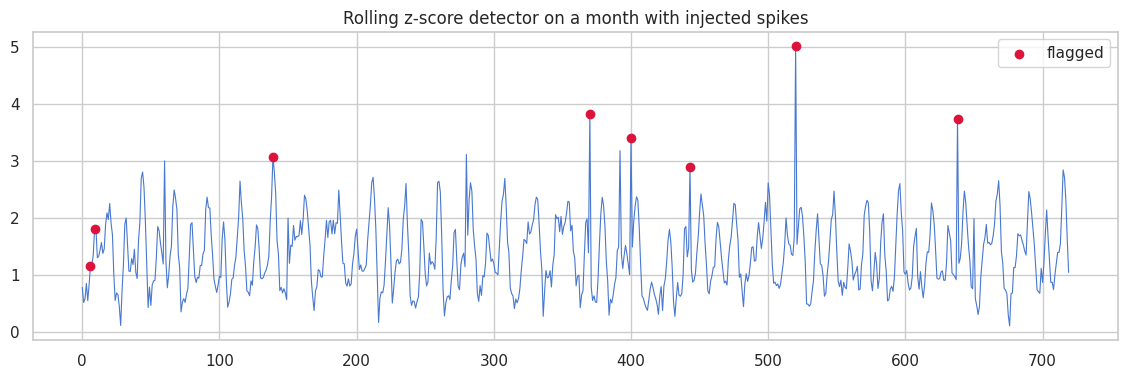

In [17]:
from models.anomaly_detector import detect_anomalies
series = data['y_hourly'].values[-720:].copy()
true_idx = np.array([60, 150, 280, 400, 520, 650])
series[true_idx] *= 3.0

rows = []
for m in ['zscore', 'iqr', 'rolling_zscore', 'isolation_forest']:
    r = detect_anomalies(series, method=m, threshold=3.0)
    found = set(r['indices']); truth = set(true_idx.tolist())
    tp = len(found & truth)
    rows.append({'method': m, 'flagged': r['count'], 'true positives': tp,
                 'precision': round(tp / max(1, len(found)), 2), 'recall': round(tp / len(truth), 2)})
display(pd.DataFrame(rows).set_index('method'))

r = detect_anomalies(series, method='rolling_zscore')
plt.figure(figsize=(14, 4)); plt.plot(series, lw=.8)
plt.scatter(r['indices'], series[r['indices']], c='crimson', zorder=5, label='flagged'); plt.legend()
plt.title('Rolling z-score detector on a month with injected spikes'); plt.show()

Global methods (z-score, IQR) flag every normal evening peak as an outlier because the series is strongly seasonal – hence low precision. The rolling z-score adapts to local behaviour; Isolation Forest on a single feature behaves like a global threshold. A stronger approach would flag points whose **forecast residual** is large – a natural extension.

## 9. Optimisation suggestions
Rule-based and transparent. Each tip says whether its saving figure was `computed` from the data or is a `heuristic` constant.

In [18]:
from models.anomaly_detector import generate_suggestions
last_week = data['y_hourly'].iloc[-168:]
tips = generate_suggestions(last_week.values, timestamps=last_week.index,
                            anomaly_result=detect_anomalies(last_week.values))
for t in tips:
    print(f"[{t['category']}] {t['title']}  (impact={t['impact']}, saving≈{t['saving_pct']}% – {t['basis']})\n   {t['detail']}\n")

[Peak Hours] Shift Usage Away From Peak Hours (5 PM – 10 PM)  (impact=high, saving≈15.3% – computed)
   Average peak-hour load is 2.12 kW, 86.4% above your off-peak average (1.14 kW). About 15.3% of your total energy is this peak excess. Running dishwashers, washing machines and EV chargers later can reduce cost on time-of-use tariffs.

[Anomaly] Investigate 5 Abnormal Consumption Spikes  (impact=medium, saving≈5.0% – heuristic)
   5 unusual readings were detected (3.0% of the data). They can indicate a faulty appliance or a device left on; compare their timestamps with your appliance schedule.



## 10. Conclusions & limitations
See the tables above for the numbers from this run. Points to state in the report:


* **Baselines matter.** Report improvement over *persistence* and *seasonal-naive*, not just R².
* **Synthetic data is built from smooth daily/weekly patterns plus noise.** Results on it show the *pipeline works*; they say little about real homes. Re-run with `USE_SYNTHETIC = False` on the UCI data for the headline results.
* **Linear vs LSTM:** with strong, regular seasonality and lag features a regularised linear model is often competitive; whichever wins, the margin and the multi-step behaviour are what to discuss.
* **Multi-step error grows with horizon** (section 6c); the web app's prediction interval is derived from these measured errors.
* **Not modelled:** weather, holidays, tariffs, occupancy – the usual drivers of real-world residential load.
* **Suggestions** are rule-based heuristics, not learned recommendations.
